# LSTM model (Extracted Features)

**Using resampled features**

Author: Pete King

We test a LSTM model using the PCA-extracted feature set, with data resampled to a weekly frequency.


In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)

from helpers import data_prep as dp
from helpers import models

IMAGE_DIR = Path.cwd() / 'images'
DATA_DIR = Path.cwd().parent / 'data' / 'downsample' / 'W' / 'train-val-test'
TRAIN_DATA_FILE = DATA_DIR / 'train_PCA_data.csv'
VAL_DATA_FILE = DATA_DIR / 'val_PCA_data.csv'
TICKER = 'SPY'
SEQUENCE_LENGTH = 4  # No. weekly timestamps in each input sequence to LSTM
BATCH_SIZE = 12  # For DataLoader (number of samples in each batch)

## I. Data Preparation

### Import and inspect financial data

In [2]:
train_df = pd.read_csv(
    TRAIN_DATA_FILE,
    index_col='date',
    parse_dates=True
)
val_df = pd.read_csv(
    VAL_DATA_FILE,
    index_col='date',
    parse_dates=True
)
# Select data (X) and label (y) -- use all features
p = re.compile(r'PCA.+')
data_cols = [col for col in train_df.columns if p.match(col) is not None]
data_cols = data_cols + [f'{TICKER}_ret-h', f'{TICKER}_vol-h']
label_col = [TICKER + '_vol_target']
train_df[data_cols].head(SEQUENCE_LENGTH)

,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hvol-4,PCA_hret-1,PCA_hret-2,PCA_hret-3,SPY_ret-h,SPY_vol-h
date,,,,,,,,,,,,,,,
2015-10-11,0.020393,-0.050569,-0.083967,-0.058499,-0.067576,-0.002795,-0.072643,-0.079753,-0.077507,0.104312,0.002316,-0.090883,-0.038069,0.014307,0.009701
2015-10-18,0.144258,0.192679,0.113998,0.055174,0.166992,0.274276,0.162710,0.094806,0.020584,0.025118,-0.079002,-0.063618,-0.125022,0.008646,0.007959
2015-10-25,-0.056647,-0.121334,-0.111703,-0.079352,-0.104368,-0.112265,-0.092717,-0.139361,-0.126741,-0.026842,0.062775,0.137901,-0.058733,0.020152,0.009382
2015-11-01,-0.094917,-0.100208,-0.130422,-0.170856,-0.163098,-0.172140,-0.177181,-0.103069,-0.153181,-0.053642,-0.100108,-0.192236,-0.164075,0.004483,0.005598


In [3]:
val_df[label_col].head(SEQUENCE_LENGTH)

,SPY_vol_target
date,
2023-01-01,0.010604
2023-01-08,0.010161
2023-01-15,0.010400
2023-01-22,0.010328


### Scale Data

We represent each feature in a uniform range (0, 1).

In [4]:
scaler = MinMaxScaler()
# Take care to fit scaler only to training data
X_train = scaler.fit_transform(train_df[data_cols])
y_train = train_df[label_col].values
X_val = scaler.transform(val_df[data_cols])
y_val = val_df[label_col].values

## II. PyTorch Multivariate LSTM Model


### Create Datasets and DataLoaders

In [5]:
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32),
    y_train.astype(np.float32),
    sequence_length=SEQUENCE_LENGTH,
    target=True
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32),
    y_val.astype(np.float32),
    sequence_length=SEQUENCE_LENGTH,
    target=True
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [6]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([4, 15])
Shape of first training label: torch.Size([1])


In [7]:
print(X_0)

tensor([[0.2144, 0.2662, 0.4444, 0.3368, 0.4544, 0.7300, 0.7103, 0.7195, 0.6249,
         0.6383, 0.5062, 0.3039, 0.1911, 0.4651, 0.1162],
        [0.2408, 0.3307, 0.5344, 0.3779, 0.5664, 0.8195, 0.7879, 0.7764, 0.6532,
         0.5962, 0.4721, 0.3120, 0.1729, 0.4384, 0.0928],
        [0.1980, 0.2474, 0.4318, 0.3292, 0.4369, 0.6946, 0.7037, 0.7001, 0.6107,
         0.5685, 0.5316, 0.3721, 0.1868, 0.4925, 0.1119],
        [0.1899, 0.2530, 0.4233, 0.2960, 0.4088, 0.6753, 0.6759, 0.7119, 0.6030,
         0.5543, 0.4632, 0.2737, 0.1646, 0.4189, 0.0611]])


In [8]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([12, 4, 15])
Shape of first batch of labels: torch.Size([12, 1])


In [9]:
print(y_0)

tensor([0.0075])


### Instantiate and train LSTM model

Here we return to a reduced hidden layer size due to the smaller set of input features.

In [10]:
## Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 24  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [11]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [12]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(15, 24, batch_first=True)
  (fc): Linear(in_features=24, out_features=1, bias=True)
)


#### Loss function and Optimizer


In [13]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [14]:
# Train and evaluate model
epochs = 100
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    if (epoch + 1) % 100 == 0:
        loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')

Training model over 100 epochs...
Epoch 100
Training loss:   0.0035783296916633844
Validation loss: 0.0024528007488697767


## III. Analyze Results

### Plot of predictions vs labels (final epoch)


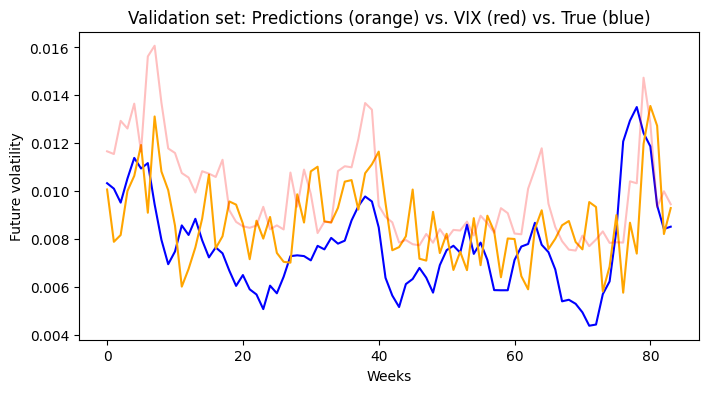

In [15]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]
# The VIX estimates annualized volatility for the next 30 days
vix = val_df['^VIX'].values[SEQUENCE_LENGTH:] / np.sqrt(252) / 100

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. VIX (red) vs. True (blue)')
ax.set_ylabel('Future volatility')
ax.set_xlabel('Weeks')
ax.plot(x, labels, color='blue')
ax.plot(x, preds, color='orange')
ax.plot(x, vix, color='red', alpha=0.25)
fig.savefig(IMAGE_DIR / 'W-LSTM-PCA')

The PCA features appear to help the model track much better than the full feature set, but it's not clear how much they help or hinder compared to the limited feature set.

In [16]:
metrics = {
    'MAE': mean_absolute_error,
    'R2': r2_score,
}
# Out-of-sample R-squared compares model performance to baseline (VIX)
r2_oos = 1 - (
    mean_absolute_error(labels, preds)
    / mean_absolute_error(labels, vix)
)
# Display results
for metric, scorer in metrics.items():
    print(f'Model {metric}: {scorer(labels, preds):.5f}')
    print(f'VIX {metric}:   {scorer(labels, vix):.5f}')
    print('---')
print(f'Model R2-OOS: {r2_oos:.2f}')

Model MAE: 0.00190
VIX MAE:   0.00236
---
Model R2: -0.43802
VIX R2:   -0.86598
---
Model R2-OOS: 0.20


Although it appears slower to react to market changes than the baseline model (vanilla VIX), our model achieves a lower MAE on the validation set than the baseline for this run.

Note: In conducting several runs for the LSTM model using resampled PCA input, I've noticed a significant amount of variation in the MAE score (attributable to the stochastic nature of the training process and complexity of the deep learning model).  Part of our model evaluation strategy will be to collect a distribution of MAE scores to provide a more robust comparison between models.  Sometimes we seem to get lucky during the training process and score better, other times worse than baseline.